In [1]:
# ── Cell 1: Load and prepare data ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("results_change_no_prior_and_entropy.csv")

# Per-entry absolute error (recomputed here rather than stored, so you can
# change the error metric later without re-running the experiment)
df["err_00"] = (df["beta_est_00"] - df["beta_true_00"]).abs()
df["err_01"] = (df["beta_est_01"] - df["beta_true_01"]).abs()
df["err_11"] = (df["beta_est_11"] - df["beta_true_11"]).abs()

# Overall per-row error summary (mean across the 3 unique entries)
df["mae"] = df[["err_00", "err_01", "err_11"]].mean(axis=1)

# inter-block error is usually the more interesting/harder one (smaller true value)
df["inter_err"] = df["err_01"]
# intra-block error, averaged over the two diagonal entries
df["intra_err"] = df[["err_00", "err_11"]].mean(axis=1)

print(f"Total rows: {len(df)}")
print(f"N values: {sorted(df['N'].unique())}")
print(f"sigma values: {sorted(df['sigma'].unique())}")
print(f"methods: {df['method'].unique()}")
df.head()

Total rows: 1200
N values: [100, 200, 500, 1000]
sigma values: [1.0, 2.0, 5.0, 10.0, 20.0]
methods: ['sbm_dpsgd' 'gaussian' 'edge_flip']


,N,sigma,epsilon,delta,method,rep,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,err_00,err_01,err_11,mae,inter_err,intra_err
0,100,1.0,5.635918,0.00001,sbm_dpsgd,0,0.2,0.02,0.2,0.223156,0.014994,0.195737,0.023156,0.005006,0.004263,0.010808,0.005006,0.013709
1,100,1.0,5.635918,0.00001,gaussian,0,0.2,0.02,0.2,0.207991,0.015065,0.197271,0.007991,0.004935,0.002729,0.005218,0.004935,0.005360
2,100,1.0,5.635918,0.00001,edge_flip,0,0.2,0.02,0.2,0.211007,0.016160,0.197030,0.011007,0.003840,0.002970,0.005939,0.003840,0.006988
3,100,1.0,5.635918,0.00001,sbm_dpsgd,1,0.2,0.02,0.2,0.203406,0.031609,0.223159,0.003406,0.011609,0.023159,0.012724,0.011609,0.013282
4,100,1.0,5.635918,0.00001,gaussian,1,0.2,0.02,0.2,0.211781,0.017319,0.222657,0.011781,0.002681,0.022657,0.012373,0.002681,0.017219


In [2]:
# ── Cell 2: Epsilon actually achieved per (N, sigma) ─────────────────────────
# Since epsilon is derived from sigma (SBM accountant) and shared across all
# 3 methods at that N, this is just a lookup table for reference.
eps_table = (
    df[["N", "sigma", "epsilon"]]
    .drop_duplicates()
    .sort_values(["N", "sigma"])
    .reset_index(drop=True)
)
eps_table

,N,sigma,epsilon
0,100,1.0,5.635918
1,100,2.0,2.668103
2,100,5.0,1.033895
3,100,10.0,0.543112
4,100,20.0,0.405612
5,200,1.0,5.635918
6,200,2.0,2.668103
7,200,5.0,1.033895
8,200,10.0,0.543112
9,200,20.0,0.405612


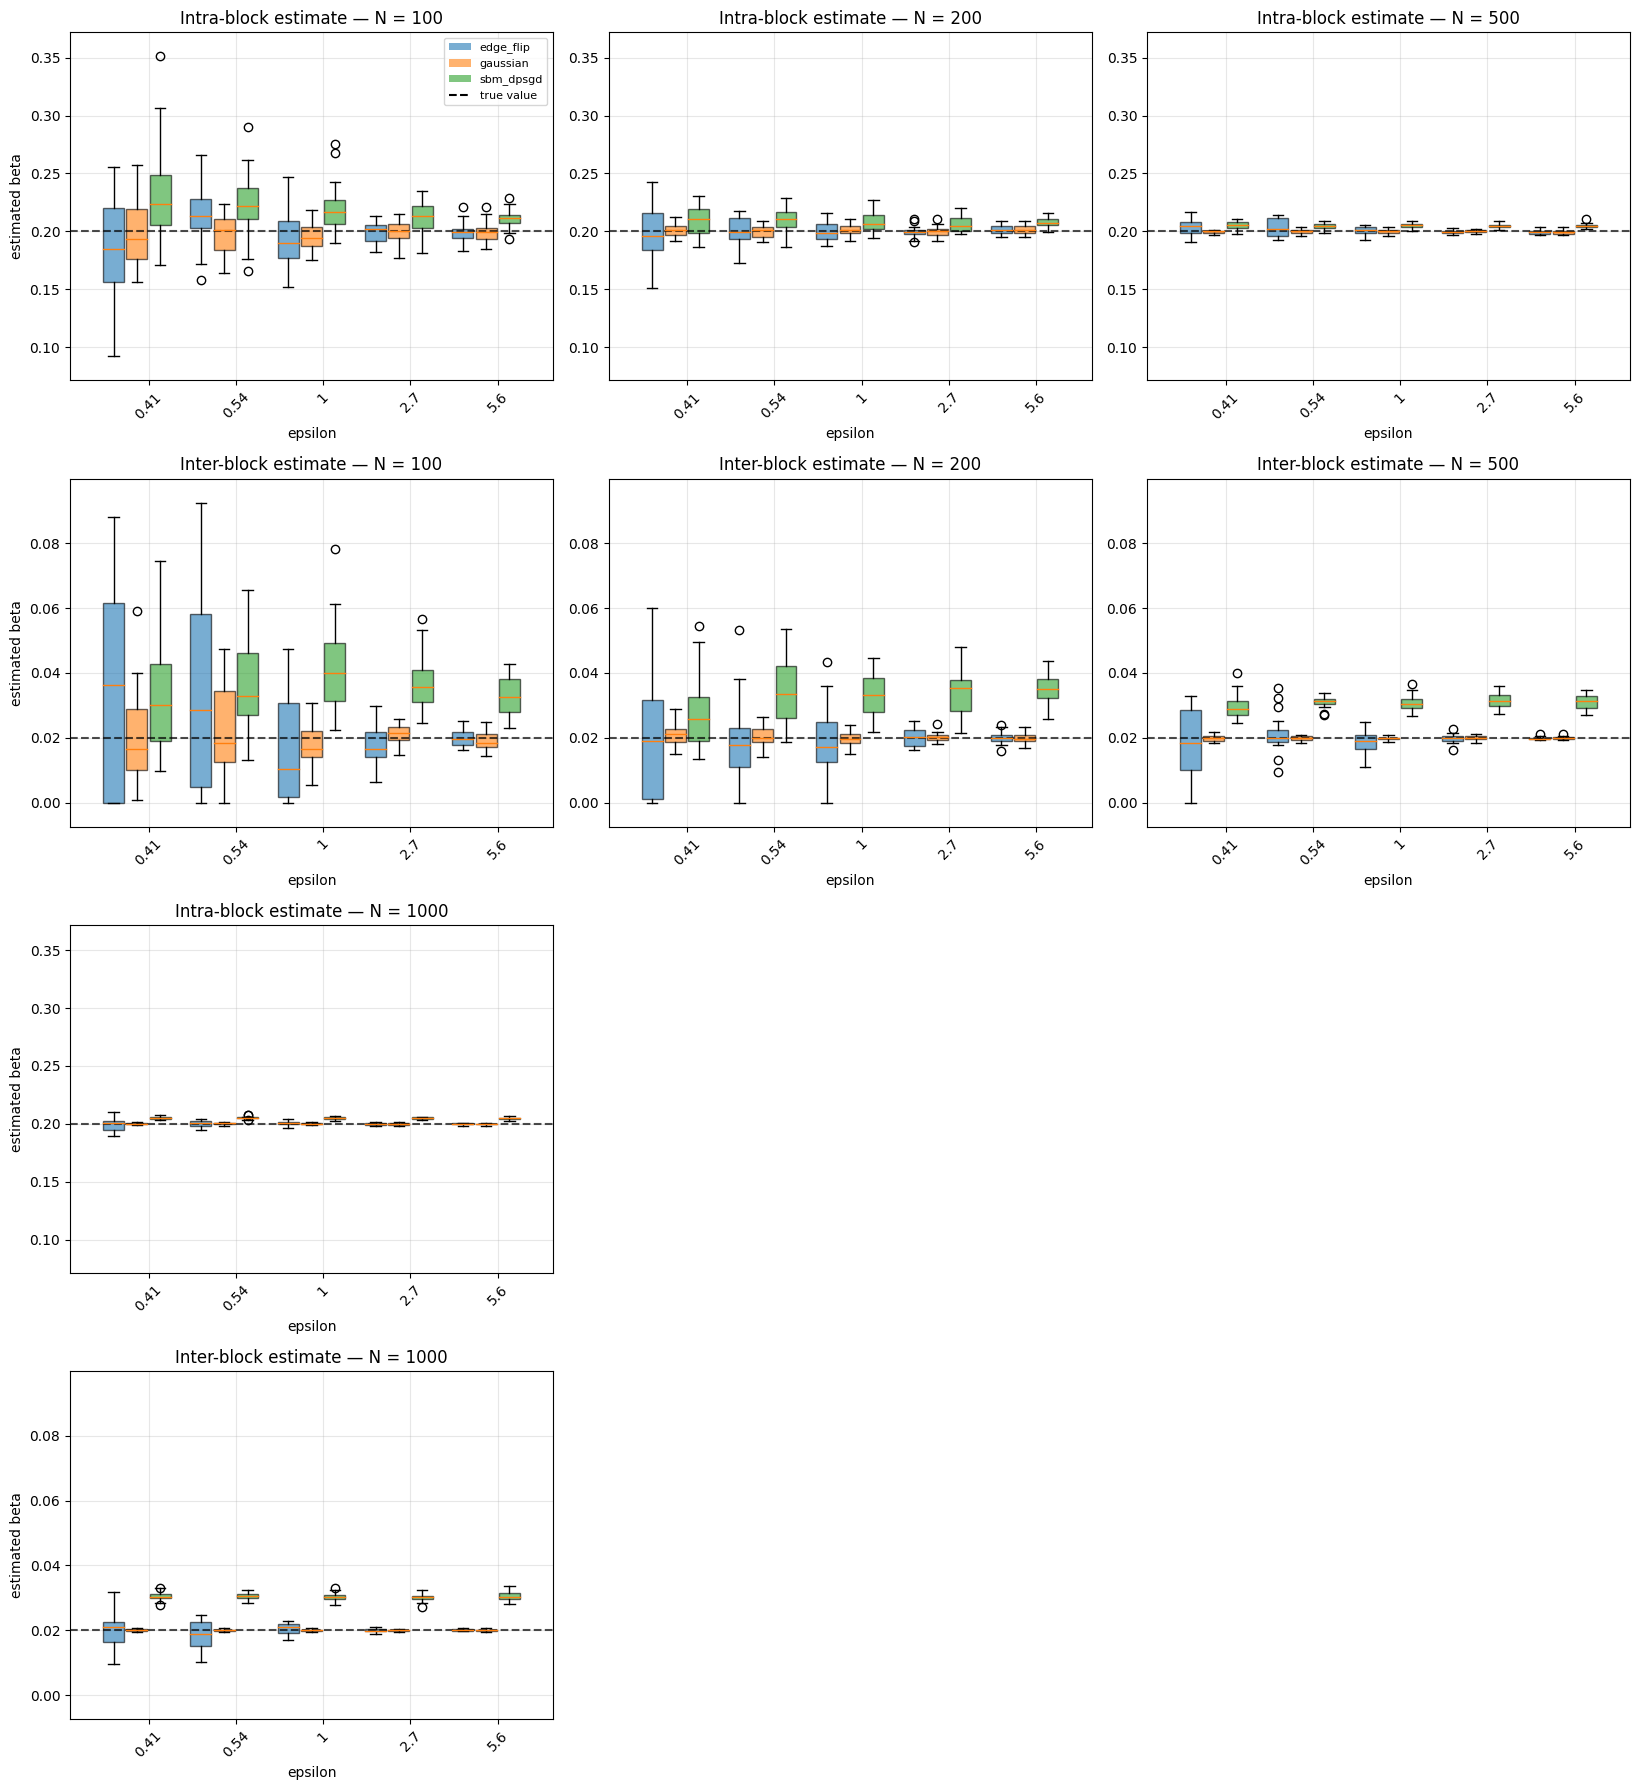

In [12]:
# ── Cell 6 (extensible grid layout): Boxplots of estimated beta vs epsilon ──
import math

Ns = sorted(df["N"].unique())
methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

MAX_COLS = 3
n_cols = min(MAX_COLS, len(Ns))
n_n_rows = math.ceil(len(Ns) / n_cols)

fig, axes = plt.subplots(
    n_n_rows * 2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_n_rows * 2),
    squeeze=False,   # no sharey here — we'll set limits manually instead
)

# ── precompute global y-limits for intra and inter panels separately ────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

# also account for the true-value reference lines, and add a little padding
intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

intra_ylim = pad(intra_ymin, intra_ymax)
inter_ylim = pad(inter_ymin, inter_ymax)

for n_idx, N in enumerate(Ns):
    grid_row = n_idx // n_cols
    grid_col = n_idx % n_cols

    sub = df[df["N"] == N].copy()
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for sub_row, (est_col, true_val, row_title, ylim) in enumerate([
        ("intra_est", true_00, "Intra-block estimate", intra_ylim),
        ("beta_est_01", true_01, "Inter-block estimate", inter_ylim),
    ]):
        ax = axes[grid_row * 2 + sub_row, grid_col]
        data, positions = [], []

        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, i in zip(bp["boxes"], range(len(data))):
            method_idx = i % len(methods)
            patch.set_facecolor(colors[method_idx % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        ax.set_ylim(ylim)   # <-- enforce shared scale across all N for this row type
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title} — N = {N}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

# hide any unused subplot cells
used_grid_positions = {(n_idx // n_cols, n_idx % n_cols) for n_idx in range(len(Ns))}
for grid_row in range(n_n_rows):
    for grid_col in range(n_cols):
        if (grid_row, grid_col) not in used_grid_positions:
            axes[grid_row * 2, grid_col].axis("off")
            axes[grid_row * 2 + 1, grid_col].axis("off")

for r in range(n_n_rows * 2):
    axes[r, 0].set_ylabel("estimated beta")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true value"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

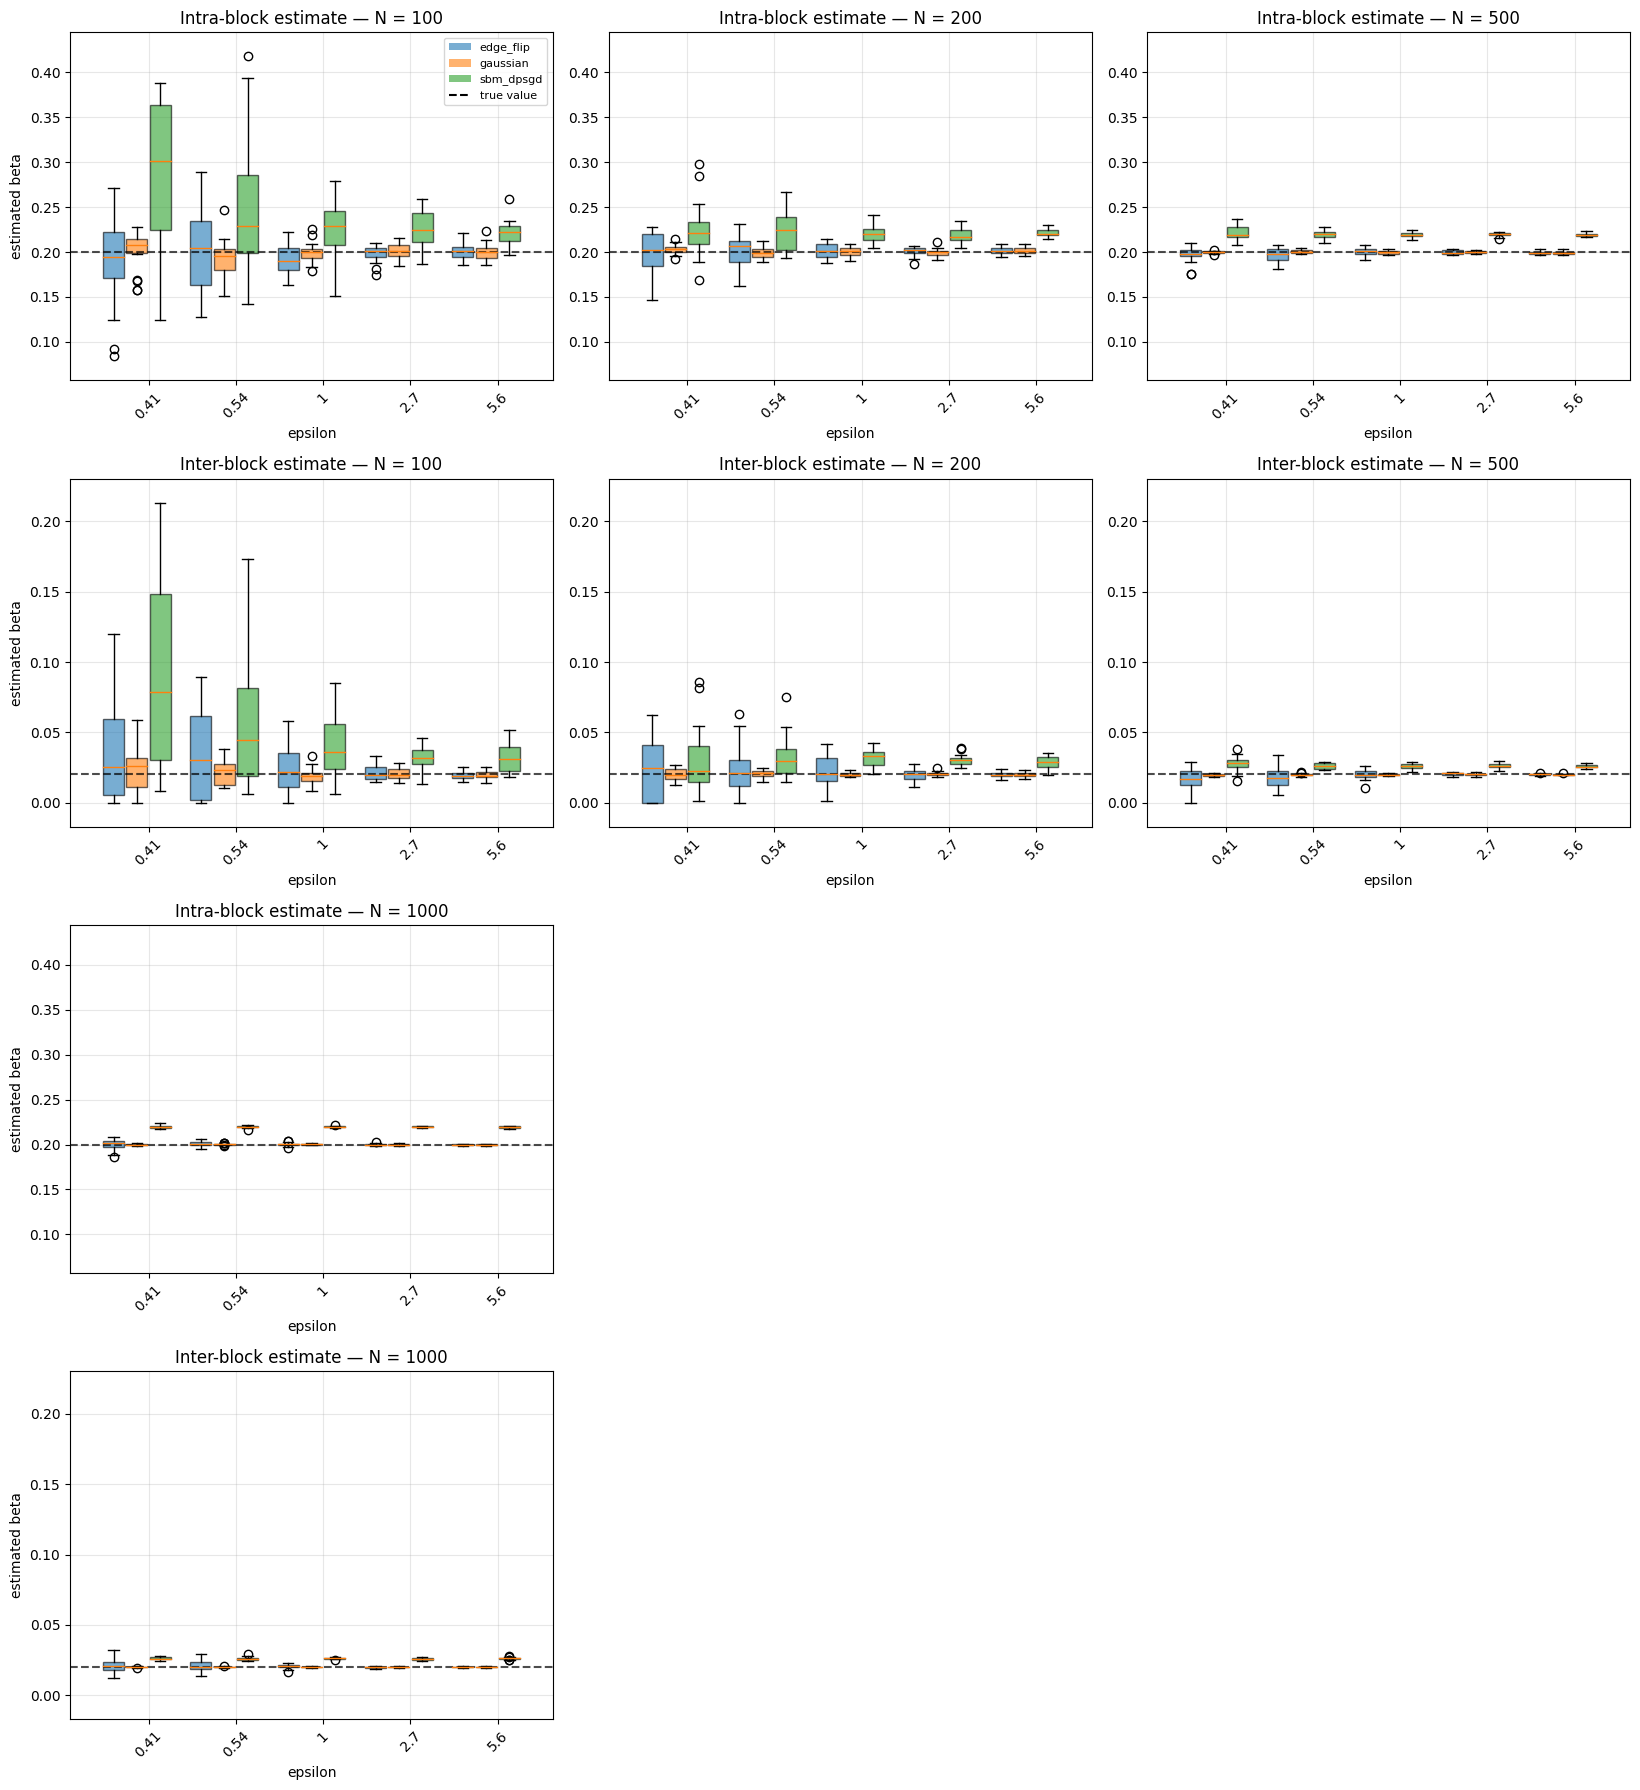

In [16]:
# ── Cell 6 (extensible grid layout): Boxplots of estimated beta vs epsilon ──
import math

Ns = sorted(df["N"].unique())
methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

MAX_COLS = 3
n_cols = min(MAX_COLS, len(Ns))
n_n_rows = math.ceil(len(Ns) / n_cols)

fig, axes = plt.subplots(
    n_n_rows * 2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_n_rows * 2),
    squeeze=False,   # no sharey here — we'll set limits manually instead
)

# ── precompute global y-limits for intra and inter panels separately ────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

# also account for the true-value reference lines, and add a little padding
intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

intra_ylim = pad(intra_ymin, intra_ymax)
inter_ylim = pad(inter_ymin, inter_ymax)

for n_idx, N in enumerate(Ns):
    grid_row = n_idx // n_cols
    grid_col = n_idx % n_cols

    sub = df[df["N"] == N].copy()
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for sub_row, (est_col, true_val, row_title, ylim) in enumerate([
        ("intra_est", true_00, "Intra-block estimate", intra_ylim),
        ("beta_est_01", true_01, "Inter-block estimate", inter_ylim),
    ]):
        ax = axes[grid_row * 2 + sub_row, grid_col]
        data, positions = [], []

        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, i in zip(bp["boxes"], range(len(data))):
            method_idx = i % len(methods)
            patch.set_facecolor(colors[method_idx % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        ax.set_ylim(ylim)   # <-- enforce shared scale across all N for this row type
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title} — N = {N}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

# hide any unused subplot cells
used_grid_positions = {(n_idx // n_cols, n_idx % n_cols) for n_idx in range(len(Ns))}
for grid_row in range(n_n_rows):
    for grid_col in range(n_cols):
        if (grid_row, grid_col) not in used_grid_positions:
            axes[grid_row * 2, grid_col].axis("off")
            axes[grid_row * 2 + 1, grid_col].axis("off")

for r in range(n_n_rows * 2):
    axes[r, 0].set_ylabel("estimated beta")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true value"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

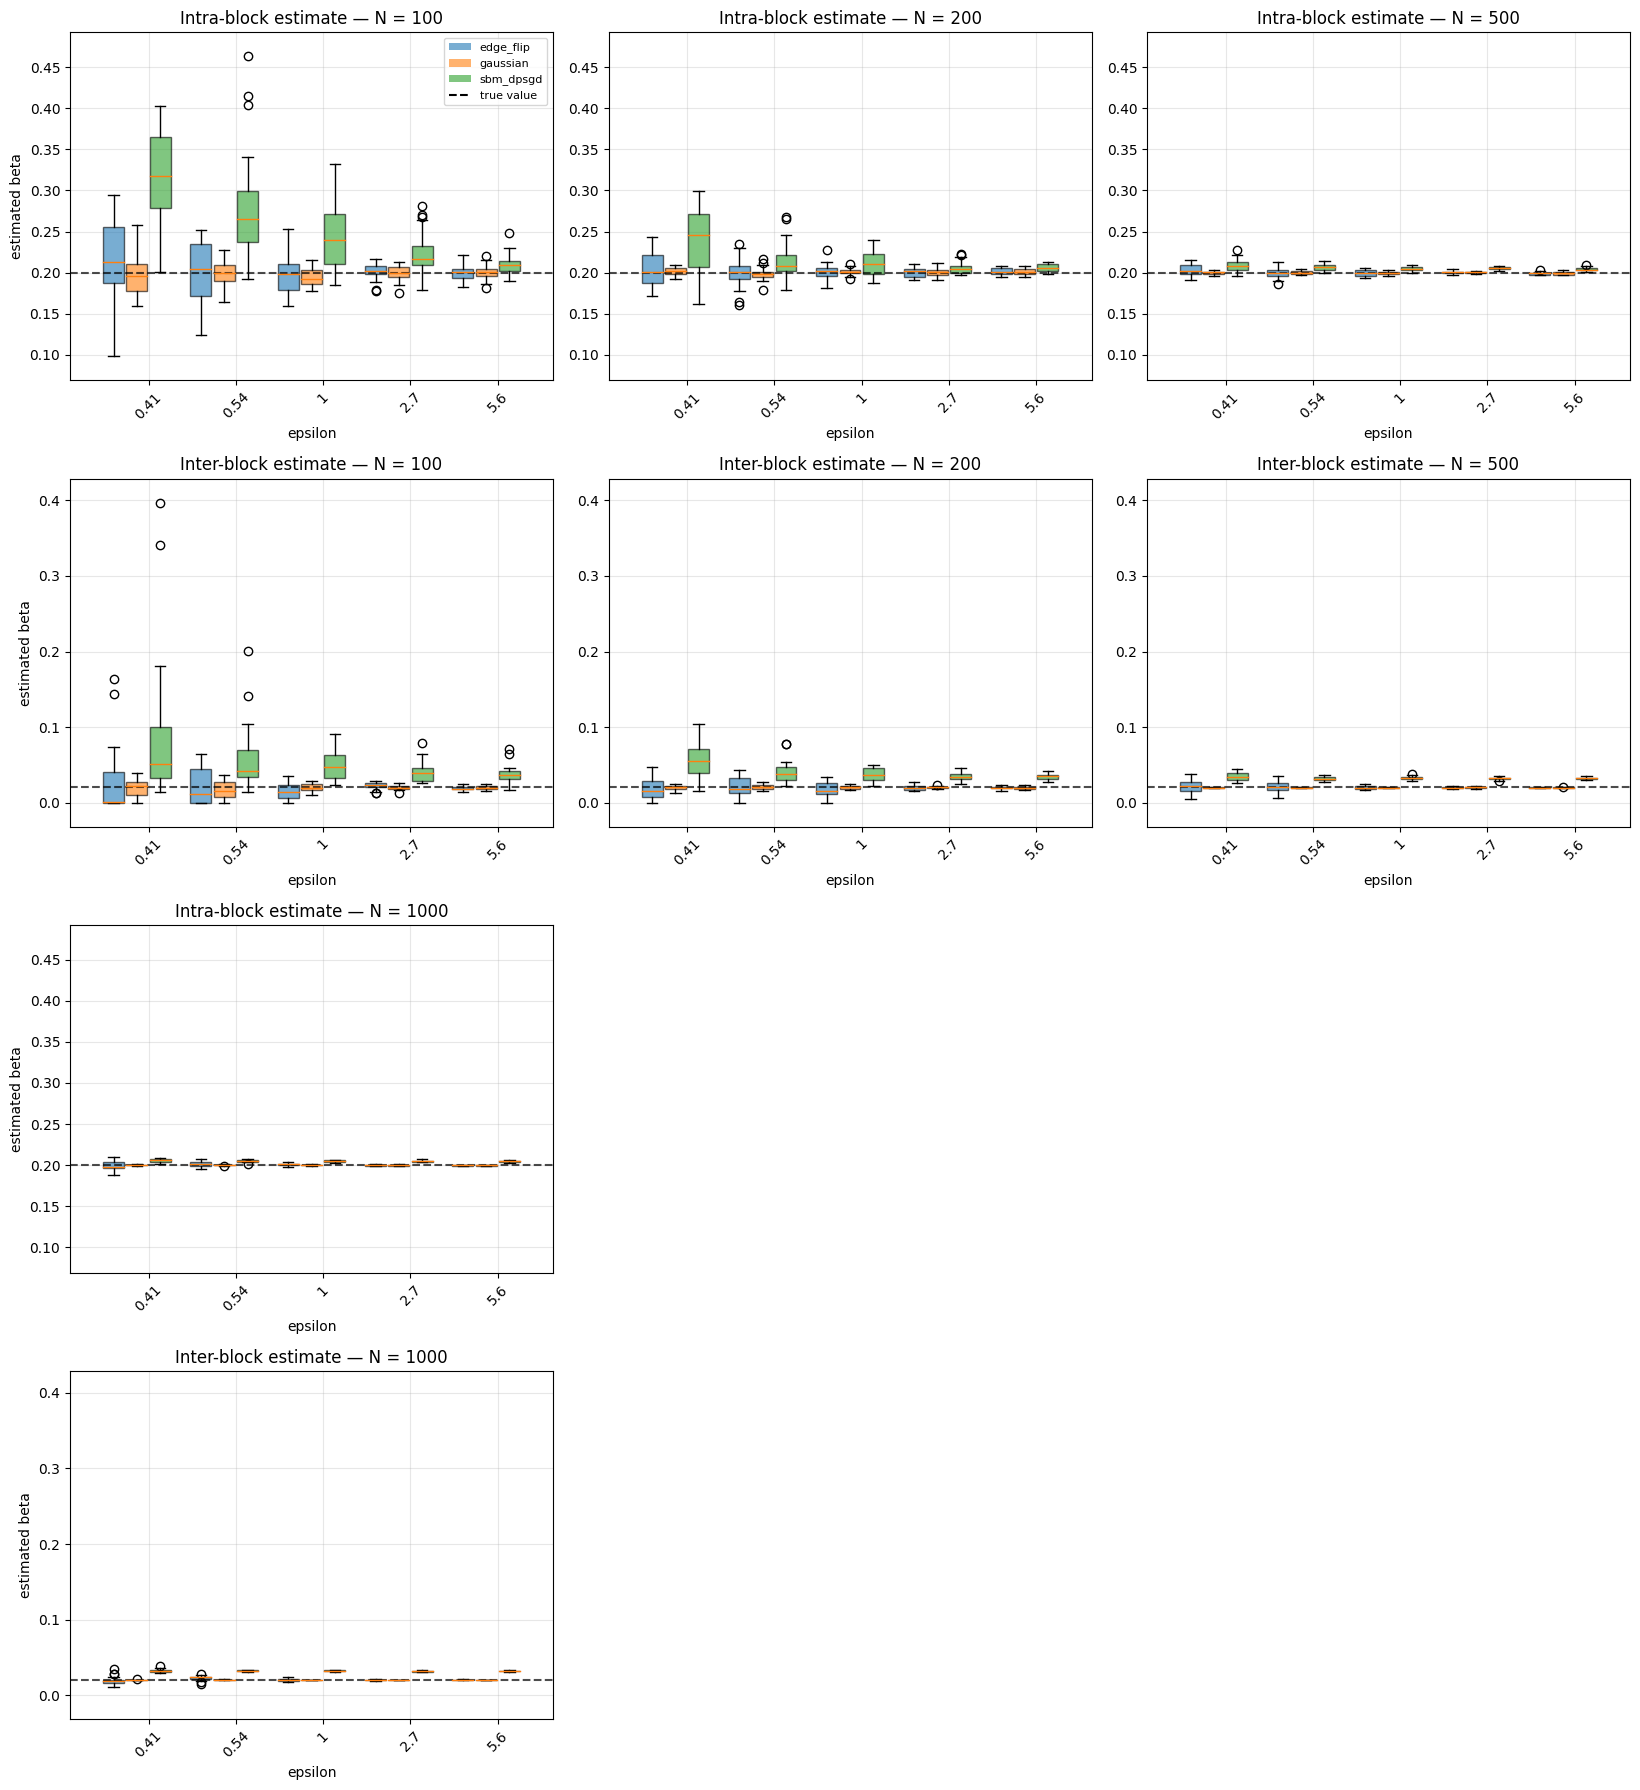

In [3]:
# ── Cell 6 (extensible grid layout): Boxplots of estimated beta vs epsilon ──
import math

Ns = sorted(df["N"].unique())
methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

MAX_COLS = 3
n_cols = min(MAX_COLS, len(Ns))
n_n_rows = math.ceil(len(Ns) / n_cols)

fig, axes = plt.subplots(
    n_n_rows * 2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_n_rows * 2),
    squeeze=False,   # no sharey here — we'll set limits manually instead
)

# ── precompute global y-limits for intra and inter panels separately ────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

# also account for the true-value reference lines, and add a little padding
intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

intra_ylim = pad(intra_ymin, intra_ymax)
inter_ylim = pad(inter_ymin, inter_ymax)

for n_idx, N in enumerate(Ns):
    grid_row = n_idx // n_cols
    grid_col = n_idx % n_cols

    sub = df[df["N"] == N].copy()
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for sub_row, (est_col, true_val, row_title, ylim) in enumerate([
        ("intra_est", true_00, "Intra-block estimate", intra_ylim),
        ("beta_est_01", true_01, "Inter-block estimate", inter_ylim),
    ]):
        ax = axes[grid_row * 2 + sub_row, grid_col]
        data, positions = [], []

        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, i in zip(bp["boxes"], range(len(data))):
            method_idx = i % len(methods)
            patch.set_facecolor(colors[method_idx % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        ax.set_ylim(ylim)   # <-- enforce shared scale across all N for this row type
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title} — N = {N}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

# hide any unused subplot cells
used_grid_positions = {(n_idx // n_cols, n_idx % n_cols) for n_idx in range(len(Ns))}
for grid_row in range(n_n_rows):
    for grid_col in range(n_cols):
        if (grid_row, grid_col) not in used_grid_positions:
            axes[grid_row * 2, grid_col].axis("off")
            axes[grid_row * 2 + 1, grid_col].axis("off")

for r in range(n_n_rows * 2):
    axes[r, 0].set_ylabel("estimated beta")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true value"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

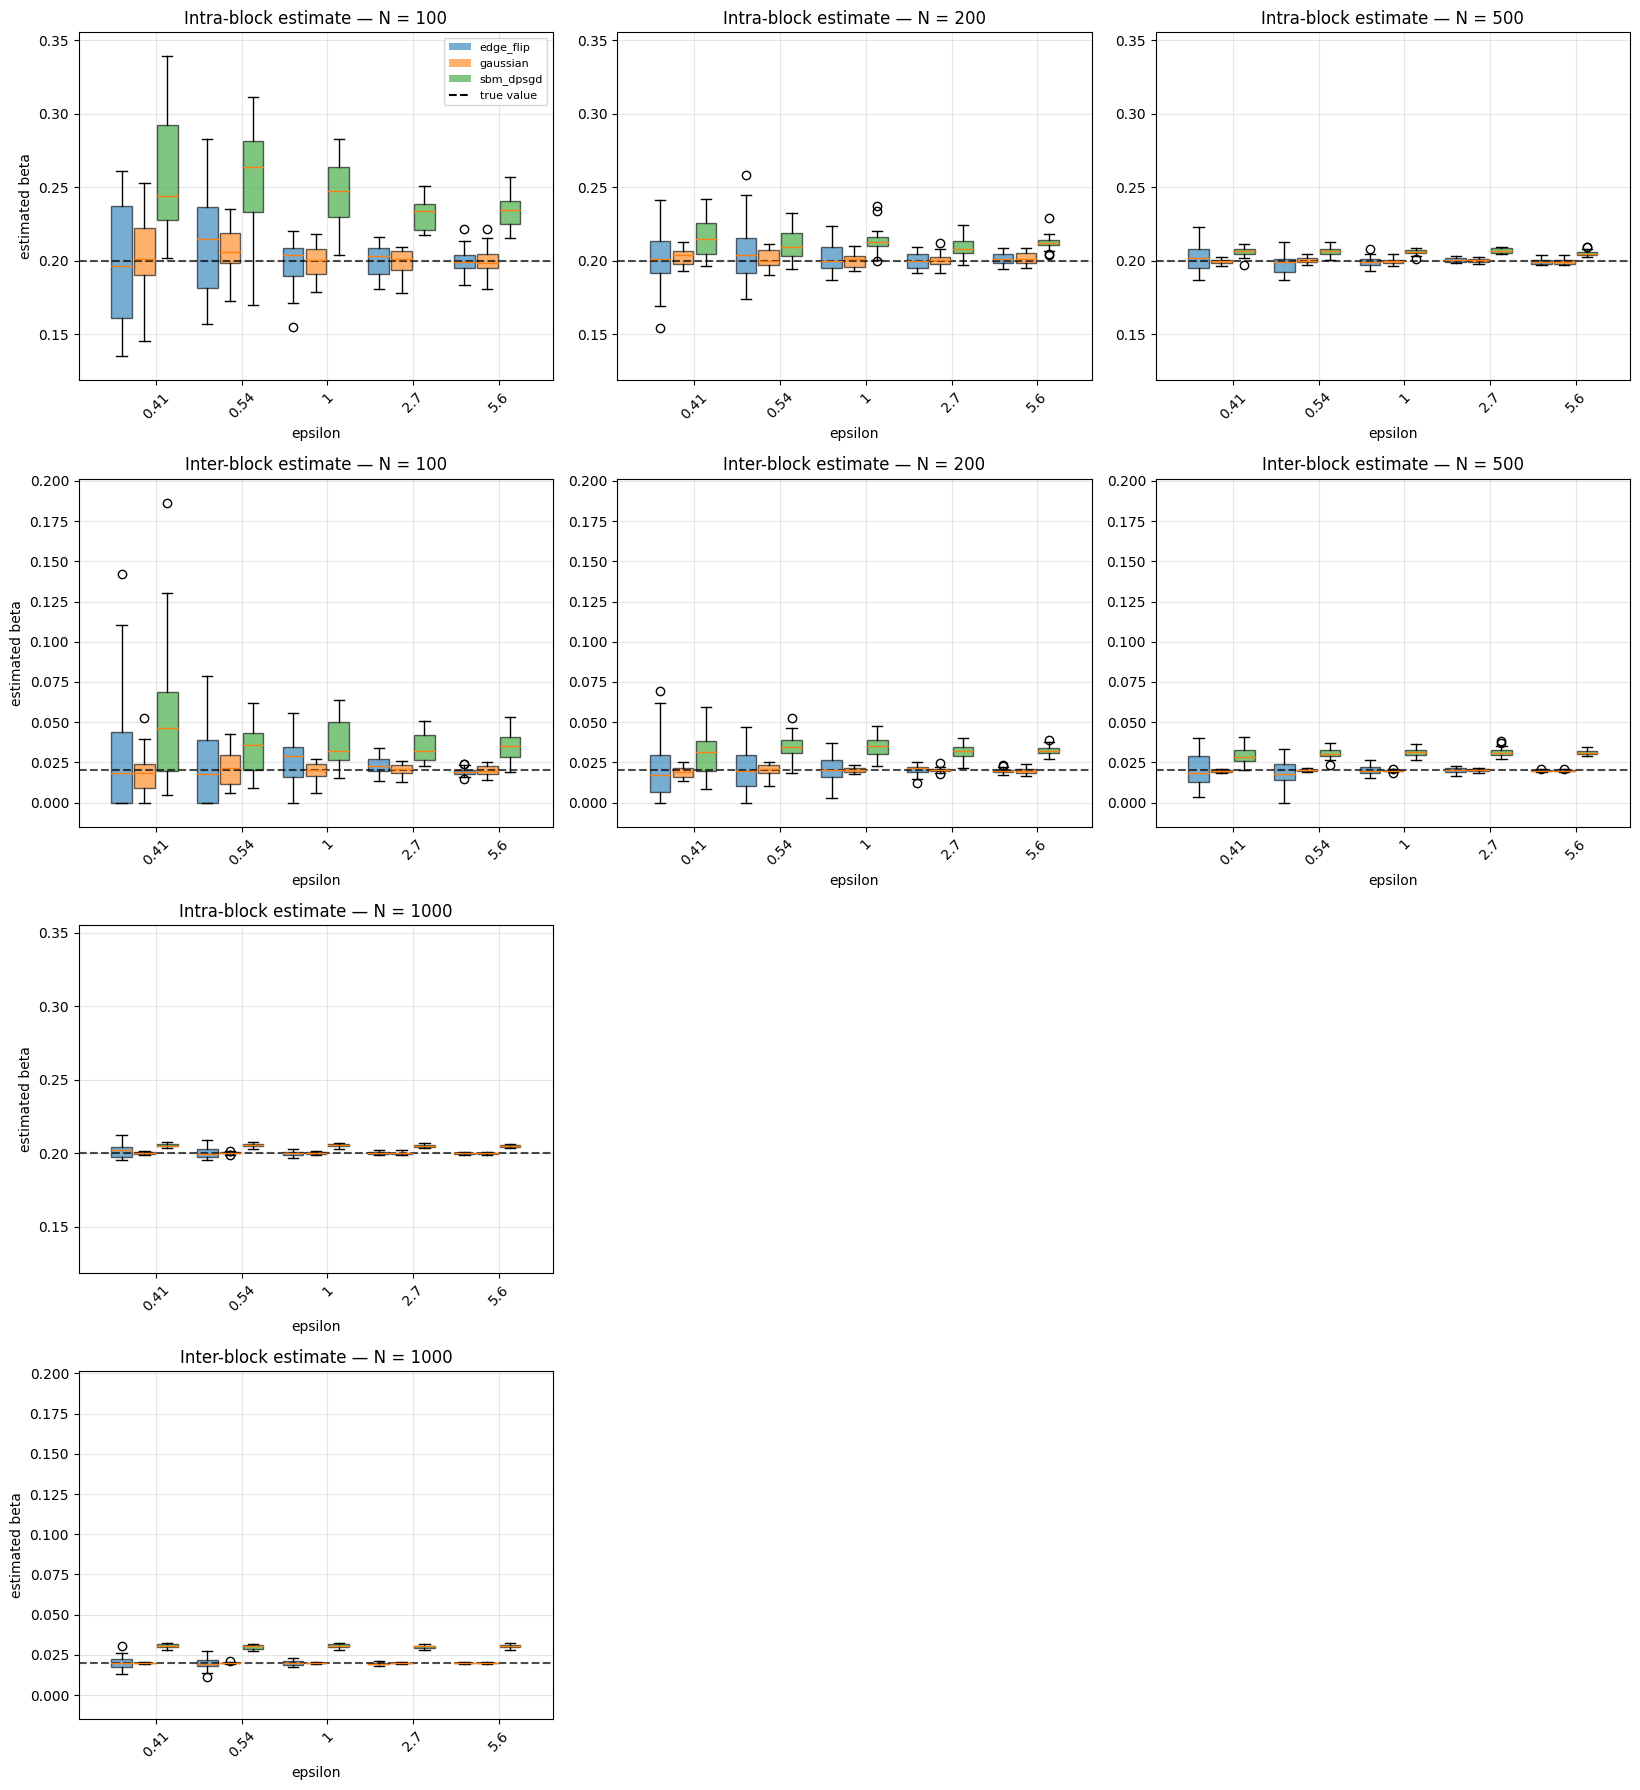

In [8]:
# ── Cell 6 (extensible grid layout): Boxplots of estimated beta vs epsilon ──
import math

Ns = sorted(df["N"].unique())
methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

MAX_COLS = 3
n_cols = min(MAX_COLS, len(Ns))
n_n_rows = math.ceil(len(Ns) / n_cols)

fig, axes = plt.subplots(
    n_n_rows * 2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_n_rows * 2),
    squeeze=False,   # no sharey here — we'll set limits manually instead
)

# ── precompute global y-limits for intra and inter panels separately ────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

# also account for the true-value reference lines, and add a little padding
intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

intra_ylim = pad(intra_ymin, intra_ymax)
inter_ylim = pad(inter_ymin, inter_ymax)

for n_idx, N in enumerate(Ns):
    grid_row = n_idx // n_cols
    grid_col = n_idx % n_cols

    sub = df[df["N"] == N].copy()
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for sub_row, (est_col, true_val, row_title, ylim) in enumerate([
        ("intra_est", true_00, "Intra-block estimate", intra_ylim),
        ("beta_est_01", true_01, "Inter-block estimate", inter_ylim),
    ]):
        ax = axes[grid_row * 2 + sub_row, grid_col]
        data, positions = [], []

        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, i in zip(bp["boxes"], range(len(data))):
            method_idx = i % len(methods)
            patch.set_facecolor(colors[method_idx % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        ax.set_ylim(ylim)   # <-- enforce shared scale across all N for this row type
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title} — N = {N}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

# hide any unused subplot cells
used_grid_positions = {(n_idx // n_cols, n_idx % n_cols) for n_idx in range(len(Ns))}
for grid_row in range(n_n_rows):
    for grid_col in range(n_cols):
        if (grid_row, grid_col) not in used_grid_positions:
            axes[grid_row * 2, grid_col].axis("off")
            axes[grid_row * 2 + 1, grid_col].axis("off")

for r in range(n_n_rows * 2):
    axes[r, 0].set_ylabel("estimated beta")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true value"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

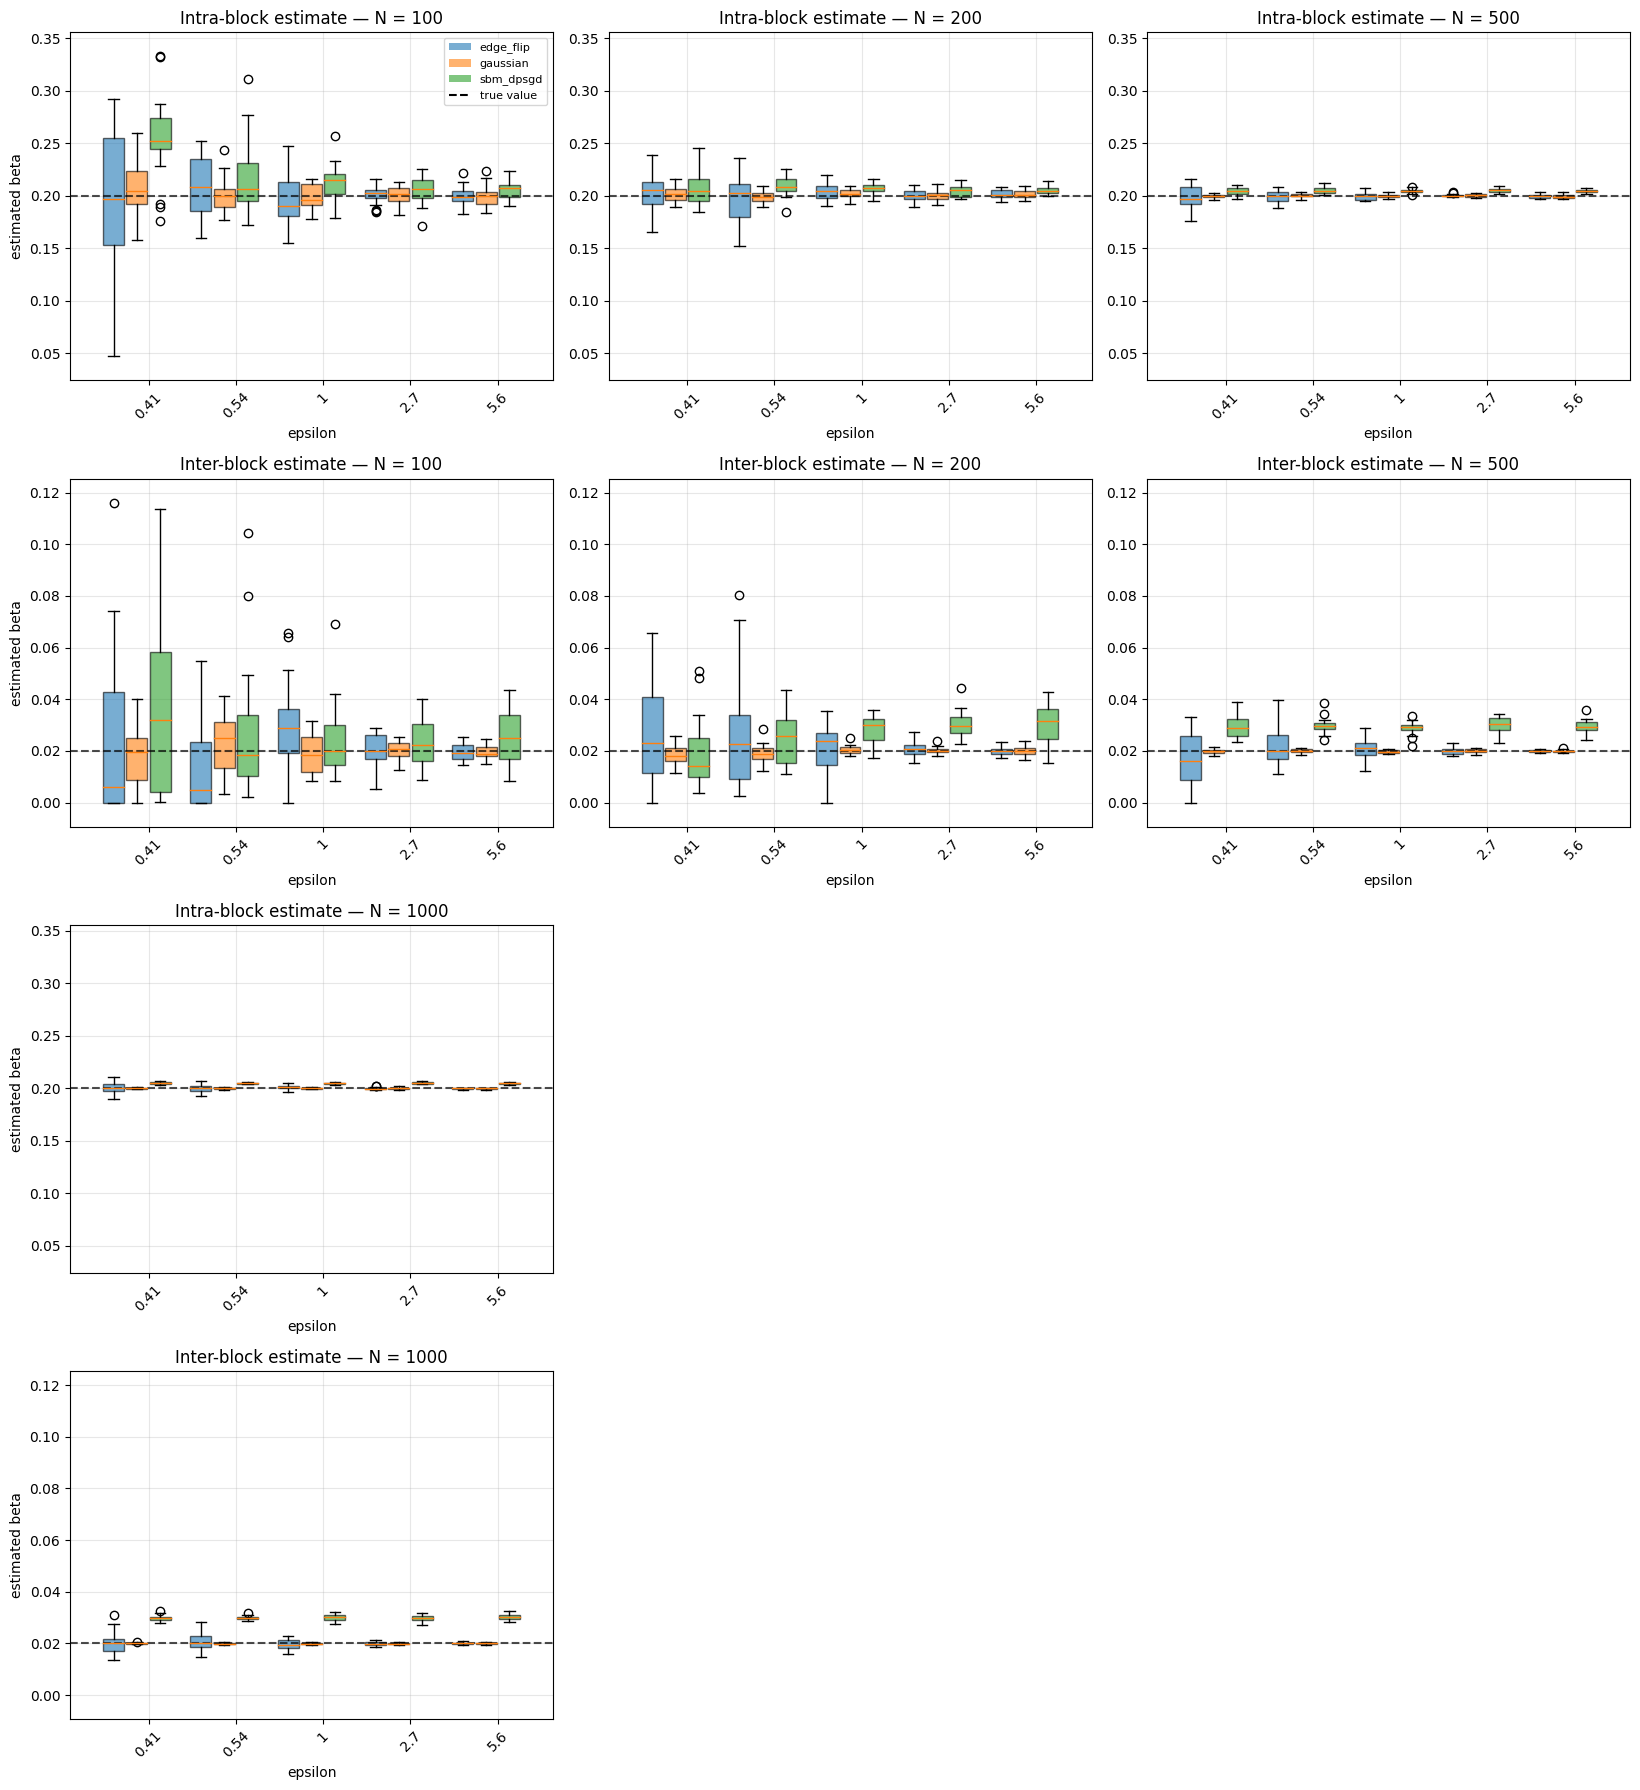

In [3]:
# ── Cell 6 (extensible grid layout): Boxplots of estimated beta vs epsilon ──
import math

Ns = sorted(df["N"].unique())
methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

MAX_COLS = 3
n_cols = min(MAX_COLS, len(Ns))
n_n_rows = math.ceil(len(Ns) / n_cols)

fig, axes = plt.subplots(
    n_n_rows * 2, n_cols,
    figsize=(5.5 * n_cols, 4.5 * n_n_rows * 2),
    squeeze=False,   # no sharey here — we'll set limits manually instead
)

# ── precompute global y-limits for intra and inter panels separately ────────
df_intra_est = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
intra_ymin, intra_ymax = df_intra_est.min(), df_intra_est.max()
inter_ymin, inter_ymax = df["beta_est_01"].min(), df["beta_est_01"].max()

# also account for the true-value reference lines, and add a little padding
intra_true_vals = df["beta_true_00"].unique()
inter_true_vals = df["beta_true_01"].unique()
intra_ymin = min(intra_ymin, intra_true_vals.min())
intra_ymax = max(intra_ymax, intra_true_vals.max())
inter_ymin = min(inter_ymin, inter_true_vals.min())
inter_ymax = max(inter_ymax, inter_true_vals.max())

def pad(lo, hi, frac=0.08):
    span = hi - lo
    if span == 0:
        span = abs(hi) if hi != 0 else 1.0
    return lo - frac * span, hi + frac * span

intra_ylim = pad(intra_ymin, intra_ymax)
inter_ylim = pad(inter_ymin, inter_ymax)

for n_idx, N in enumerate(Ns):
    grid_row = n_idx // n_cols
    grid_col = n_idx % n_cols

    sub = df[df["N"] == N].copy()
    true_00 = sub["beta_true_00"].iloc[0]
    true_01 = sub["beta_true_01"].iloc[0]
    sub["intra_est"] = sub[["beta_est_00", "beta_est_11"]].mean(axis=1)

    eps_vals = sorted(sub["epsilon"].unique())
    width = 0.8 / len(methods)

    for sub_row, (est_col, true_val, row_title, ylim) in enumerate([
        ("intra_est", true_00, "Intra-block estimate", intra_ylim),
        ("beta_est_01", true_01, "Inter-block estimate", inter_ylim),
    ]):
        ax = axes[grid_row * 2 + sub_row, grid_col]
        data, positions = [], []

        for e_idx, eps in enumerate(eps_vals):
            for m_idx, method in enumerate(methods):
                vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)][est_col]
                if len(vals) == 0:
                    continue
                data.append(vals.values)
                positions.append(e_idx + (m_idx - len(methods) / 2) * width)

        bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
        for patch, i in zip(bp["boxes"], range(len(data))):
            method_idx = i % len(methods)
            patch.set_facecolor(colors[method_idx % len(colors)])
            patch.set_alpha(0.6)

        ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)

        ax.set_ylim(ylim)   # <-- enforce shared scale across all N for this row type
        ax.set_xticks(range(len(eps_vals)))
        ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
        ax.set_title(f"{row_title} — N = {N}")
        ax.set_xlabel("epsilon")
        ax.grid(alpha=0.3)

# hide any unused subplot cells
used_grid_positions = {(n_idx // n_cols, n_idx % n_cols) for n_idx in range(len(Ns))}
for grid_row in range(n_n_rows):
    for grid_col in range(n_cols):
        if (grid_row, grid_col) not in used_grid_positions:
            axes[grid_row * 2, grid_col].axis("off")
            axes[grid_row * 2 + 1, grid_col].axis("off")

for r in range(n_n_rows * 2):
    axes[r, 0].set_ylabel("estimated beta")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="true value"))
axes[0, 0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()